# Text Analytics - Part 3 - Exercise 5

**Exercise 5: POS tagging with an MLP**

The idea is the window based model (idea form the lecture)

- take a small window around the current word,
- map the words of the window to embeddings,
- concatenate the embeddings,
- pass the vector through an MLP,
- predict the POS tag of the middle word.

I also include the required baseline: for each word, predict the most frequent POS tag it had in the training set. For unseen words, the baseline predicts the most frequent tag overall.

## 1. Imports and settings

I keep the coding style close to the professor's PyTorch notebook: `nn.Module`, `TensorDataset`, `DataLoader`, `CrossEntropyLoss`, `Adam`, and a standard train/evaluation loop.

In [2]:
## If need , becasue in my pc it was needed
## !pip -q install --upgrade --force-reinstall scipy scikit-learn

In [3]:
import os
import sys
import random
import urllib.request
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, average_precision_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from IPython.display import display

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Load the treebank

I use the English EWT treebank from Universal Dependencies.

From the CoNLL-U files I keep only:

- the word form,
- the UPOS tag.

I ignore dependencies and other annotations (form the exercise question).

In [4]:
DATA_DIR = Path("ud_english_ewt")
DATA_DIR.mkdir(exist_ok=True)

UD_URLS = {
    "train": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu",
    "dev": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-dev.conllu",
    "test": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu",
}

def download_if_needed(split_name, url):
    out_path = DATA_DIR / f"{split_name}.conllu"
    if not out_path.exists():
        print(f"Downloading {split_name} data...")
        urllib.request.urlretrieve(url, out_path)
    return out_path

paths = {split: download_if_needed(split, url) for split, url in UD_URLS.items()}
paths

{'train': PosixPath('ud_english_ewt/train.conllu'),
 'dev': PosixPath('ud_english_ewt/dev.conllu'),
 'test': PosixPath('ud_english_ewt/test.conllu')}

In [5]:
def read_conllu_words_and_upos(path):
    """Small Conll U reader. We only need FORM and UPOS."""
    sentences = []
    tags = []
    current_words = []
    current_tags = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "":
                if current_words:
                    sentences.append(current_words)
                    tags.append(current_tags)
                    current_words = []
                    current_tags = []
                continue

            if line.startswith("#"):
                continue

            parts = line.split("\t")
            if len(parts) < 4:
                continue

            token_id = parts[0]
            if "-" in token_id or "." in token_id:
                continue

            current_words.append(parts[1])
            current_tags.append(parts[3])

    if current_words:
        sentences.append(current_words)
        tags.append(current_tags)

    return sentences, tags

train_words_raw, train_tags = read_conllu_words_and_upos(paths["train"])
dev_words_raw, dev_tags = read_conllu_words_and_upos(paths["dev"])
test_words_raw, test_tags = read_conllu_words_and_upos(paths["test"])

print("Train sentences:", len(train_words_raw))
print("Dev sentences:", len(dev_words_raw))
print("Test sentences:", len(test_words_raw))
print("Example words:", train_words_raw[0])
print("Example tags:", train_tags[0])

Train sentences: 12544
Dev sentences: 2001
Test sentences: 2077
Example words: ['Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'Abdullah', 'al', '-', 'Ani', ',', 'the', 'preacher', 'at', 'the', 'mosque', 'in', 'the', 'town', 'of', 'Qaim', ',', 'near', 'the', 'Syrian', 'border', '.']
Example tags: ['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'ADP', 'PROPN', 'PUNCT', 'ADP', 'DET', 'ADJ', 'NOUN', 'PUNCT']


## 3. Some info from our dataset

In [6]:
def count_tokens(sentences):
    return sum(len(s) for s in sentences)

def avg_sentence_length(sentences):
    return count_tokens(sentences) / len(sentences)

stats_df = pd.DataFrame({
    "split": ["train", "dev", "test"],
    "sentences": [len(train_words_raw), len(dev_words_raw), len(test_words_raw)],
    "tokens": [count_tokens(train_words_raw), count_tokens(dev_words_raw), count_tokens(test_words_raw)],
    "average_sentence_length": [
        avg_sentence_length(train_words_raw),
        avg_sentence_length(dev_words_raw),
        avg_sentence_length(test_words_raw),
    ],
})

stats_df

,split,sentences,tokens,average_sentence_length
0,train,12544,204578,16.308833
1,dev,2001,25148,12.567716
2,test,2077,25094,12.081849


In [7]:
train_tag_counter = Counter(tag for sent in train_tags for tag in sent)

tag_distribution = pd.DataFrame({
    "tag": list(train_tag_counter.keys()),
    "train_count": list(train_tag_counter.values()),
}).sort_values("train_count", ascending=False)

tag_distribution

,tag,train_count
3,NOUN,34751
1,PUNCT,23596
4,VERB,22576
8,PRON,18678
6,ADP,17714
5,DET,16299
2,ADJ,13136
7,AUX,12815
0,PROPN,12620
12,ADV,10172


### Comment on the dataset

For this exercise, i kept only the words, sentences, and UPOS tags.

The dataset is already split into training, development, and test subsets. The training set contains around **12k sentences** and **205k tokens**. The development set contains **2k sentences** and **25k tokens**, while the test set contains **2k sentences** and **25k tokens**.

The average sentence length is **16.31 tokens** in the training set, **12.57 tokens** in the development set, and **12.08 tokens** in the test set. I report the above to see amount of training material available for the POS tagger.


## 4. Vocabulary and preprocessing

The word vocabulary is built only from the training set.

I lowercase the words to reduce sparsity. This means that `The` and `the` are treated as the same word. This may lose some capitalization information, but it keeps the model simple.

Rare words are mapped to `<UNK>` like my previous assignment. I also use boundary tokens `<BOS>` and `<EOS>` so that words at the beginning and end of a sentence still have a complete window.

In [8]:
PAD = "<PAD>"
UNK = "<UNK>"
BOS = "<BOS>"
EOS = "<EOS>"

MIN_COUNT = 2
WINDOW_RADIUS = 2
WINDOW_SIZE = 2 * WINDOW_RADIUS + 1

def normalize_word(word):
    return word.lower()

train_words = [[normalize_word(w) for w in sent] for sent in train_words_raw]
dev_words = [[normalize_word(w) for w in sent] for sent in dev_words_raw]
test_words = [[normalize_word(w) for w in sent] for sent in test_words_raw]

word_counter = Counter()
for sent in train_words:
    word_counter.update(sent)

known_words = sorted([w for w, c in word_counter.items() if c >= MIN_COUNT])
word_vocab = [PAD, UNK, BOS, EOS] + known_words
word_to_id = {w: i for i, w in enumerate(word_vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}

tag_vocab = sorted(train_tag_counter.keys())
tag_to_id = {tag: i for i, tag in enumerate(tag_vocab)}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

print("Word vocabulary size:", len(word_vocab))
print("Number of POS tags:", len(tag_vocab))
print("POS tags:", tag_vocab)

Word vocabulary size: 8869
Number of POS tags: 17
POS tags: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X']


## 5. Create window examples

For every word I create one example:

`two previous words + current word + two next words -> POS tag of current word`

So the input contains 5 word ids and the output is one POS tag id.

In [9]:
def word_id(word):
    return word_to_id.get(word, word_to_id[UNK])

def make_window_dataset(sentences, tags):
    X_rows = []
    y_rows = []

    for words, sent_tags in zip(sentences, tags):
        padded_words = [BOS] * WINDOW_RADIUS + words + [EOS] * WINDOW_RADIUS

        for i, tag in enumerate(sent_tags):
            center = i + WINDOW_RADIUS
            window_words = padded_words[center - WINDOW_RADIUS:center + WINDOW_RADIUS + 1]
            X_rows.append([word_id(w) for w in window_words])
            y_rows.append(tag_to_id[tag])

    X = torch.tensor(X_rows, dtype=torch.long)
    y = torch.tensor(y_rows, dtype=torch.long)
    return X, y

X_train, y_train = make_window_dataset(train_words, train_tags)
X_dev, y_dev = make_window_dataset(dev_words, dev_tags)
X_test, y_test = make_window_dataset(test_words, test_tags)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("First window ids:", X_train[0].tolist())
print("First target tag:", id_to_tag[int(y_train[0])])

X_train: torch.Size([204578, 5])
y_train: torch.Size([204578])
First window ids: [2, 2, 662, 47, 8845]
First target tag: PROPN


In [10]:
BATCH_SIZE = 1024

train_dataset = TensorDataset(X_train, y_train)
dev_dataset = TensorDataset(X_dev, y_dev)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Training batches:", len(train_loader))
print("Dev batches:", len(dev_loader))
print("Test batches:", len(test_loader))

Training batches: 200
Dev batches: 25
Test batches: 25


## 6. Baseline: most frequent tag per word

For each word, I predict the POS tag that the word had most often in the training set. If the word did not appear in training, I predict the most frequent tag overall.

In [11]:
word_tag_counts = defaultdict(Counter)
for words, sent_tags in zip(train_words, train_tags):
    for word, tag in zip(words, sent_tags):
        word_tag_counts[word][tag] += 1

most_common_tag = train_tag_counter.most_common(1)[0][0]
print("Most common tag overall:", most_common_tag)

word_to_best_tag = {}
for word, counts in word_tag_counts.items():
    word_to_best_tag[word] = counts.most_common(1)[0][0]

def baseline_predict(sentences):
    pred_ids = []
    for sent in sentences:
        for word in sent:
            if word in word_to_best_tag:
                pred_tag = word_to_best_tag[word]
            else:
                pred_tag = most_common_tag
            pred_ids.append(tag_to_id[pred_tag])
    return np.array(pred_ids)

baseline_train_pred = baseline_predict(train_words)
baseline_dev_pred = baseline_predict(dev_words)
baseline_test_pred = baseline_predict(test_words)

print("First 10 baseline predictions:")
print([id_to_tag[int(x)] for x in baseline_train_pred[:10]])

Most common tag overall: NOUN
First 10 baseline predictions:
['PROPN', 'PUNCT', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'PROPN', 'PROPN', 'PROPN']


## 7. Embeddings and MLP model

I use pre trained GloVe 50 dim embeddings when they can be loaded.

The embeddings are fine tuned during training.

In [12]:
USE_PRETRAINED_EMBEDDINGS = True
EMBEDDING_DIM = 50

def build_embedding_matrix():
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(0.0, 0.05, size=(len(word_vocab), EMBEDDING_DIM)).astype(np.float32)
    matrix[word_to_id[PAD]] = np.zeros(EMBEDDING_DIM, dtype=np.float32)

    if not USE_PRETRAINED_EMBEDDINGS:
        print("Using random embeddings.")
        return torch.tensor(matrix, dtype=torch.float32)

    try:
        try:
            import gensim.downloader as api
        except Exception:
            print("Installing gensim...")
            import subprocess
            subprocess.check_call([sys.executable, "-m", "pip", "install", "gensim", "-q"])
            import gensim.downloader as api

        print("Loading GloVe 50d embeddings. This may take a little time the first time.")
        glove = api.load("glove-wiki-gigaword-50")

        found = 0
        for word, idx in word_to_id.items():
            if word in glove:
                matrix[idx] = glove[word]
                found += 1

        print(f"Words initialized from GloVe: {found} / {len(word_vocab)}")

    except Exception as e:
        print("Could not load GloVe. The model will continue with random embeddings.")
        print("Reason:", repr(e))

    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix = build_embedding_matrix()
print("Embedding matrix shape:", embedding_matrix.shape)

Installing gensim...
Loading GloVe 50d embeddings. This may take a little time the first time.
[==================================================] 100.0% 66.0/66.0MB downloaded
Words initialized from GloVe: 8530 / 8869
Embedding matrix shape: torch.Size([8869, 50])


In [13]:
class WindowPOSTagger(nn.Module):
    def __init__(self, embedding_matrix, window_size, hidden_dim, dropout_prob, num_tags):
        super().__init__()

        vocab_size, embedding_dim = embedding_matrix.shape

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=word_to_id[PAD])
        self.embedding.weight.data.copy_(embedding_matrix)
        self.embedding.weight.requires_grad = True

        self.net = nn.Sequential(
            nn.Linear(window_size * embedding_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(hidden_dim // 2, num_tags),
        )

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.reshape(emb.shape[0], -1)
        scores = self.net(emb)
        return scores

## 8. Training loop

I monitor the training and development loss after every epoch.

The final model is the one from the epoch with the lowest development loss.

In [14]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_items = 0

    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            scores = model(X_batch)
            loss = criterion(scores, y_batch)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * y_batch.shape[0]
        total_items += y_batch.shape[0]

    return total_loss / total_items

def train_pos_mlp(model, train_loader, dev_loader, epochs=10, learning_rate=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    best_dev_loss = float("inf")
    best_state = None
    rows = []

    for epoch in range(1, epochs + 1):
        train_loss = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
        dev_loss = run_one_epoch(model, dev_loader, criterion, optimizer=None)

        rows.append({"epoch": epoch, "train_loss": train_loss, "dev_loss": dev_loss})
        print(f"Epoch {epoch:02d} | train loss: {train_loss:.4f} | dev loss: {dev_loss:.4f}")

        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, pd.DataFrame(rows)

## 9. Train the POS tagger

The parameters are grouped here so they can be changed easily.

In case it was slow (which was not).

In [15]:
HIDDEN_DIM = 256
DROPOUT_PROB = 0.30
EPOCHS = 10
LEARNING_RATE = 0.001

pos_mlp = WindowPOSTagger(
    embedding_matrix=embedding_matrix,
    window_size=WINDOW_SIZE,
    hidden_dim=HIDDEN_DIM,
    dropout_prob=DROPOUT_PROB,
    num_tags=len(tag_vocab),
).to(device)

pos_mlp, loss_history = train_pos_mlp(
    model=pos_mlp,
    train_loader=train_loader,
    dev_loader=dev_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
)

loss_history

Epoch 01 | train loss: 1.0956 | dev loss: 0.4919
Epoch 02 | train loss: 0.4036 | dev loss: 0.3539
Epoch 03 | train loss: 0.2869 | dev loss: 0.3050
Epoch 04 | train loss: 0.2297 | dev loss: 0.2793
Epoch 05 | train loss: 0.1949 | dev loss: 0.2695
Epoch 06 | train loss: 0.1704 | dev loss: 0.2656
Epoch 07 | train loss: 0.1534 | dev loss: 0.2636
Epoch 08 | train loss: 0.1381 | dev loss: 0.2580
Epoch 09 | train loss: 0.1252 | dev loss: 0.2637
Epoch 10 | train loss: 0.1130 | dev loss: 0.2624


,epoch,train_loss,dev_loss
0,1,1.095581,0.491900
1,2,0.403604,0.353860
2,3,0.286866,0.305040
3,4,0.229700,0.279268
4,5,0.194945,0.269454
5,6,0.170373,0.265599
6,7,0.153430,0.263556
7,8,0.138066,0.257954
8,9,0.125151,0.263724
9,10,0.112969,0.262393


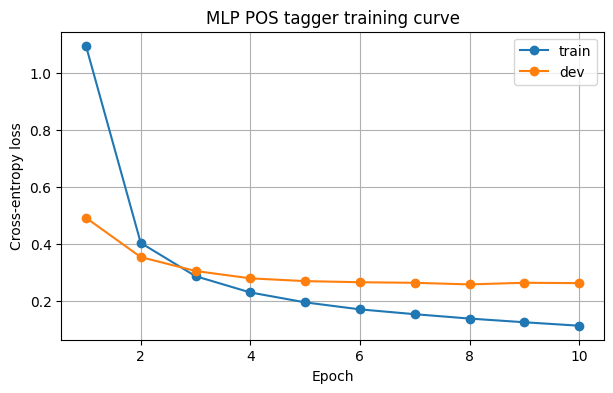

In [16]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history["epoch"], loss_history["train_loss"], marker="o", label="train")
plt.plot(loss_history["epoch"], loss_history["dev_loss"], marker="o", label="dev")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("MLP POS tagger training curve")
plt.legend()
plt.grid(True)
plt.show()

## 10. Evaluation metrics

Precision, recall, F1, and precision-recall AUC:

- for each POS tag,
- for the macro-average,
- for train, development, and test subsets,
- for the baseline and for the MLP.

For the MLP I use the softmax probabilities for PR-AUC. For the baseline, I convert the hard prediction to a one hot score vector.

In [17]:
def predict_mlp(model, data_loader):
    model.eval()
    all_true = []
    all_pred = []
    all_probs = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            scores = model(X_batch)
            probs = torch.softmax(scores, dim=1)
            pred = torch.argmax(probs, dim=1)

            all_true.extend(y_batch.numpy().tolist())
            all_pred.extend(pred.cpu().numpy().tolist())
            all_probs.append(probs.cpu().numpy())

    return np.array(all_true), np.array(all_pred), np.vstack(all_probs)

def one_hot_scores(pred_ids, num_classes):
    scores = np.zeros((len(pred_ids), num_classes), dtype=float)
    scores[np.arange(len(pred_ids)), pred_ids] = 1.0
    return scores

def make_metric_rows(model_name, split_name, y_true, y_pred, y_scores):
    labels = list(range(len(tag_vocab)))
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=labels, zero_division=0
    )

    rows = []
    pr_auc_values = []

    for i, tag in enumerate(tag_vocab):
        true_binary = (y_true == i).astype(int)
        if true_binary.sum() == 0:
            pr_auc = np.nan
        else:
            pr_auc = average_precision_score(true_binary, y_scores[:, i])
            pr_auc_values.append(pr_auc)

        rows.append({
            "model": model_name,
            "split": split_name,
            "tag": tag,
            "precision": precision[i],
            "recall": recall[i],
            "f1": f1[i],
            "pr_auc": pr_auc,
            "support": support[i],
        })

    rows.append({
        "model": model_name,
        "split": split_name,
        "tag": "MACRO_AVERAGE",
        "precision": np.mean(precision),
        "recall": np.mean(recall),
        "f1": np.mean(f1),
        "pr_auc": np.nanmean(pr_auc_values),
        "support": np.sum(support),
    })

    return rows

In [18]:
y_train_np = y_train.numpy()
y_dev_np = y_dev.numpy()
y_test_np = y_test.numpy()

baseline_train_scores = one_hot_scores(baseline_train_pred, len(tag_vocab))
baseline_dev_scores = one_hot_scores(baseline_dev_pred, len(tag_vocab))
baseline_test_scores = one_hot_scores(baseline_test_pred, len(tag_vocab))

mlp_train_true, mlp_train_pred, mlp_train_scores = predict_mlp(pos_mlp, train_loader)
mlp_dev_true, mlp_dev_pred, mlp_dev_scores = predict_mlp(pos_mlp, dev_loader)
mlp_test_true, mlp_test_pred, mlp_test_scores = predict_mlp(pos_mlp, test_loader)

metric_rows = []
metric_rows += make_metric_rows("Most frequent tag baseline", "train", y_train_np, baseline_train_pred, baseline_train_scores)
metric_rows += make_metric_rows("Most frequent tag baseline", "dev", y_dev_np, baseline_dev_pred, baseline_dev_scores)
metric_rows += make_metric_rows("Most frequent tag baseline", "test", y_test_np, baseline_test_pred, baseline_test_scores)
metric_rows += make_metric_rows("Window MLP POS tagger", "train", mlp_train_true, mlp_train_pred, mlp_train_scores)
metric_rows += make_metric_rows("Window MLP POS tagger", "dev", mlp_dev_true, mlp_dev_pred, mlp_dev_scores)
metric_rows += make_metric_rows("Window MLP POS tagger", "test", mlp_test_true, mlp_test_pred, mlp_test_scores)

all_metrics = pd.DataFrame(metric_rows)
all_metrics.head()

,model,split,tag,precision,recall,f1,pr_auc,support
0,Most frequent tag baseline,train,ADJ,0.906797,0.935445,0.920898,0.852403,13136
1,Most frequent tag baseline,train,ADP,0.863043,0.881167,0.872011,0.770775,17714
2,Most frequent tag baseline,train,ADV,0.922216,0.801907,0.857864,0.749381,10172
3,Most frequent tag baseline,train,AUX,0.917188,0.904019,0.910556,0.835167,12815
4,Most frequent tag baseline,train,CCONJ,0.982145,0.995364,0.988711,0.977744,6687


In [19]:
# Clean macro table for the report.
macro_results = all_metrics[all_metrics["tag"] == "MACRO_AVERAGE"].copy()
macro_results.sort_values(["split", "model"])

,model,split,tag,precision,recall,f1,pr_auc,support
35,Most frequent tag baseline,dev,MACRO_AVERAGE,0.836325,0.774837,0.791781,0.684912,25148
89,Window MLP POS tagger,dev,MACRO_AVERAGE,0.894537,0.833580,0.848580,0.888026,25148
53,Most frequent tag baseline,test,MACRO_AVERAGE,0.819922,0.775515,0.786675,0.686075,25094
107,Window MLP POS tagger,test,MACRO_AVERAGE,0.868905,0.846331,0.856253,0.898254,25094
17,Most frequent tag baseline,train,MACRO_AVERAGE,0.896462,0.872635,0.880112,0.793365,204578
71,Window MLP POS tagger,train,MACRO_AVERAGE,0.966270,0.911805,0.926000,0.960816,204578


In [20]:
# Per-tag results for the test set.
test_per_tag = all_metrics[
    (all_metrics["split"] == "test") &
    (all_metrics["tag"] != "MACRO_AVERAGE")
].copy()

test_per_tag.sort_values("f1", ascending=False)

,model,split,tag,precision,recall,f1,pr_auc,support
40,Most frequent tag baseline,test,CCONJ,0.987854,0.994565,0.991198,0.982645,736
102,Window MLP POS tagger,test,PUNCT,0.995109,0.985788,0.990427,0.998963,3096
48,Most frequent tag baseline,test,PUNCT,0.994139,0.986111,0.990109,0.982045,3096
94,Window MLP POS tagger,test,CCONJ,0.990476,0.989130,0.989803,0.997285,736
95,Window MLP POS tagger,test,DET,0.991480,0.981550,0.986490,0.998192,1897
93,Window MLP POS tagger,test,AUX,0.982524,0.983798,0.983161,0.996499,1543
100,Window MLP POS tagger,test,PRON,0.977554,0.986137,0.981827,0.996445,2164
99,Window MLP POS tagger,test,PART,0.966309,0.972265,0.969278,0.995541,649
41,Most frequent tag baseline,test,DET,0.955533,0.974170,0.964761,0.932804,1897
91,Window MLP POS tagger,test,ADP,0.933873,0.969383,0.951296,0.985779,2025


### Comment on the main evaluation results

The main evaluation results show that the window-based MLP POS tagger improves clearly over the most frequent tag baseline.

On the test set, the baseline achieved a F1 score of **0.78**, while the MLP achieved a score of **0.85**. The MLP also improved some precision from **0.81** to **0.86**, recall from **0.77** to **0.84**, and macro PR-AUC from **0.68** to **0.89**.

The same pattern appears on the development set. This is important because the development set was used during training and model selection.

The training curve is also reasonable. The training loss decreases wihtout steep movements from epoch to epoch. The development loss decreases until around epoch 8, where it reaches its best value. After that, the training loss continues to decrease, but the development loss does not improve much (again diminishing r). I kept the model parameters from the epoch with the best development loss so we dont overfit.

Looking at the per tag results, the MLP performs very well on frequent and clear tags such as `PUNCT`, `CCONJ`, `DET`, `AUX` etc etc. For example, on the test set the MLP gets F1 scores of **0.99** for `PUNCT`, **0.98** for `CCONJ`,  and **0.98** for `DET`.

The harder tags are mostly rare categories, such as `X`, `PROPN`, `NUM`, `SYM`, `SCONJ`, `INTJ`, `NOUN`, and `ADJ`. This makes sense, because proper names, numbers, symbols, and rare words are more difficult to tag correctly.


## 11. Extra check: error analysis

Apart from the main metric tables, I also check which POS tags are easier and harder for the MLP.

This is useful because the  average gives one number, but it does not show where the model makes mistakes.

Here I look at:

- the best POS tags by F1,
- the worst POS tags by F1,
- the most common confusions, for example cases where the true tag is one POS tag but the model predicts another.

In [21]:
from sklearn.metrics import confusion_matrix

# Per-tag test results of the MLP only.
mlp_test_per_tag = all_metrics[
    (all_metrics["model"] == "Window MLP POS tagger") &
    (all_metrics["split"] == "test") &
    (all_metrics["tag"] != "MACRO_AVERAGE")
].copy()

print("Best POS tags by F1 on the test set")
display(mlp_test_per_tag.sort_values("f1", ascending=False).head(8))

print("Worst POS tags by F1 on the test set")
display(mlp_test_per_tag.sort_values("f1", ascending=True).head(8))

# Confusion matrix for the MLP on the test set.
cm = confusion_matrix(mlp_test_true, mlp_test_pred, labels=list(range(len(tag_vocab))))

confusion_rows = []
for true_id, true_tag in enumerate(tag_vocab):
    for pred_id, pred_tag in enumerate(tag_vocab):
        if true_id == pred_id:
            continue
        count = cm[true_id, pred_id]
        if count > 0:
            confusion_rows.append({
                "true_tag": true_tag,
                "predicted_tag": pred_tag,
                "count": int(count)
            })

confusions_df = pd.DataFrame(confusion_rows).sort_values("count", ascending=False)
print("Most common confusions of the MLP on the test set")
display(confusions_df.head(15))

Best POS tags by F1 on the test set


,model,split,tag,precision,recall,f1,pr_auc,support
102,Window MLP POS tagger,test,PUNCT,0.995109,0.985788,0.990427,0.998963,3096
94,Window MLP POS tagger,test,CCONJ,0.990476,0.989130,0.989803,0.997285,736
95,Window MLP POS tagger,test,DET,0.991480,0.981550,0.986490,0.998192,1897
93,Window MLP POS tagger,test,AUX,0.982524,0.983798,0.983161,0.996499,1543
100,Window MLP POS tagger,test,PRON,0.977554,0.986137,0.981827,0.996445,2164
99,Window MLP POS tagger,test,PART,0.966309,0.972265,0.969278,0.995541,649
91,Window MLP POS tagger,test,ADP,0.933873,0.969383,0.951296,0.985779,2025
105,Window MLP POS tagger,test,VERB,0.928243,0.928599,0.928421,0.979901,2605


Worst POS tags by F1 on the test set


,model,split,tag,precision,recall,f1,pr_auc,support
106,Window MLP POS tagger,test,X,0.000000,0.000000,0.000000,0.028026,42
101,Window MLP POS tagger,test,PROPN,0.817187,0.719518,0.765249,0.879856,2075
98,Window MLP POS tagger,test,NUM,0.852000,0.785978,0.817658,0.884237,542
104,Window MLP POS tagger,test,SYM,0.820513,0.849558,0.834783,0.870006,113
103,Window MLP POS tagger,test,SCONJ,0.903904,0.783854,0.839609,0.901198,384
96,Window MLP POS tagger,test,INTJ,0.968750,0.768595,0.857143,0.887087,121
97,Window MLP POS tagger,test,NOUN,0.834545,0.918748,0.874625,0.956189,4123
90,Window MLP POS tagger,test,ADJ,0.891168,0.874720,0.882868,0.953738,1788


Most common confusions of the MLP on the test set


,true_tag,predicted_tag,count
87,PROPN,NOUN,459
60,NOUN,PROPN,157
117,VERB,NOUN,105
4,ADJ,NOUN,99
62,NOUN,VERB,65
53,NOUN,ADJ,60
69,NUM,PROPN,56
98,SCONJ,ADP,55
18,ADV,ADP,43
7,ADJ,VERB,43


### comment on the error analysis

The confusion table helps us understand the model better. POS tags that appear very often, or words that have a very stable grammatical role, are usually easier. More difficult cases are usually tags that depend strongly on context, or tags that are rare in the dataset.

## 12. Simple tagging examples

I also show some real test sentences. This helps us see where the MLP agrees or disagrees with the baseline and the gold tags.

In [22]:
def predict_tags_for_sentence(model, words):
    model.eval()
    words_norm = [normalize_word(w) for w in words]
    padded_words = [BOS] * WINDOW_RADIUS + words_norm + [EOS] * WINDOW_RADIUS

    X_rows = []
    for i in range(len(words_norm)):
        center = i + WINDOW_RADIUS
        window_words = padded_words[center - WINDOW_RADIUS:center + WINDOW_RADIUS + 1]
        X_rows.append([word_id(w) for w in window_words])

    X = torch.tensor(X_rows, dtype=torch.long).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(X), dim=1)
        pred_ids = torch.argmax(probs, dim=1).cpu().numpy()

    return [id_to_tag[int(i)] for i in pred_ids]

def baseline_tags_for_sentence(words):
    pred_tags = []
    for word in words:
        word_norm = normalize_word(word)
        pred_tags.append(word_to_best_tag.get(word_norm, most_common_tag))
    return pred_tags

def show_test_example(sentence_index):
    words = test_words_raw[sentence_index]
    gold = test_tags[sentence_index]
    baseline = baseline_tags_for_sentence(words)
    mlp_pred = predict_tags_for_sentence(pos_mlp, words)

    display(pd.DataFrame({
        "word": words,
        "gold_tag": gold,
        "baseline_tag": baseline,
        "mlp_tag": mlp_pred,
    }))

show_test_example(0)
show_test_example(5)
show_test_example(10)

,word,gold_tag,baseline_tag,mlp_tag
0,What,PRON,PRON,PRON
1,if,SCONJ,SCONJ,SCONJ
2,Google,PROPN,PROPN,PROPN
3,Morphed,VERB,NOUN,VERB
4,Into,ADP,ADP,ADP
5,GoogleOS,PROPN,NOUN,NOUN
6,?,PUNCT,PUNCT,PUNCT


,word,gold_tag,baseline_tag,mlp_tag
0,Google,PROPN,PROPN,PROPN
1,is,AUX,AUX,AUX
2,a,DET,DET,DET
3,nice,ADJ,ADJ,ADJ
4,search,NOUN,NOUN,NOUN
5,engine,NOUN,NOUN,NOUN
6,.,PUNCT,PUNCT,PUNCT


,word,gold_tag,baseline_tag,mlp_tag
0,I,PRON,PRON,PRON
1,doubt,VERB,NOUN,VERB
2,the,DET,DET,DET
3,very,ADV,ADV,ADV
4,few,ADJ,ADJ,ADJ
5,who,PRON,PRON,PRON
6,actually,ADV,ADV,ADV
7,read,VERB,VERB,VERB
8,my,PRON,PRON,PRON
9,blog,NOUN,NOUN,NOUN


In [23]:
custom_sentence = "The president said that the United States is ready .".split()
custom_tags = predict_tags_for_sentence(pos_mlp, custom_sentence)

pd.DataFrame({
    "word": custom_sentence,
    "predicted_pos_tag": custom_tags,
})

,word,predicted_pos_tag
0,The,DET
1,president,NOUN
2,said,VERB
3,that,SCONJ
4,the,DET
5,United,ADJ
6,States,PROPN
7,is,AUX
8,ready,ADJ
9,.,PUNCT


### Short comment on the simple examples

These examples are a quick qualitative check of the POS tagger. The MLP usually performs better when the sentence is simple and the surrounding words give useful context. The more detailed error analysis is shown in the next section.



## 13. Extra checks: best and worst examples

The metric tables are useful, but they do not show the actual mistakes of the tagger.

For this reason, I also add a another check. I flatten the test set token by token and keep:

- the word,
- the gold POS tag,
- the baseline prediction,
- the MLP prediction,
- whether the word was known from the training vocabulary,
- the confidence of the MLP prediction.

Then I automatically find some good and bad sentences from the test set:

- **best examples**: sentences where the MLP makes no mistakes or very few mistakes,
- **worst examples**: sentences where the MLP makes more mistakes.

This is not used for tuning the model. It is just an extra check to understand the results better.


In [24]:
def flatten_test_tokens():
    """
    Create one row per test token. This makes error analysis easier.
    The order matches the flattened predictions produced by the test DataLoader.
    """
    rows = []
    flat_index = 0

    for sent_id, (words_original, words_norm, gold_tags) in enumerate(
        zip(test_words_raw, test_words, test_tags)
    ):
        baseline_tags = baseline_tags_for_sentence(words_original)

        for token_id, (word_original, word_norm, gold_tag, baseline_tag) in enumerate(
            zip(words_original, words_norm, gold_tags, baseline_tags)
        ):
            mlp_pred_id = int(mlp_test_pred[flat_index])
            mlp_pred_tag = id_to_tag[mlp_pred_id]
            mlp_conf = float(np.max(mlp_test_scores[flat_index]))

            rows.append({
                "sent_id": sent_id,
                "token_id": token_id,
                "word": word_original,
                "word_normalized": word_norm,
                "gold_tag": gold_tag,
                "baseline_tag": baseline_tag,
                "mlp_tag": mlp_pred_tag,
                "baseline_correct": baseline_tag == gold_tag,
                "mlp_correct": mlp_pred_tag == gold_tag,
                "known_in_train_vocab": word_norm in known_words,
                "mlp_confidence": mlp_conf,
            })

            flat_index += 1

    return pd.DataFrame(rows)


test_token_analysis = flatten_test_tokens()

test_token_analysis.head(15)


,sent_id,token_id,word,word_normalized,gold_tag,baseline_tag,mlp_tag,baseline_correct,mlp_correct,known_in_train_vocab,mlp_confidence
0,0,0,What,what,PRON,PRON,PRON,True,True,True,0.996229
1,0,1,if,if,SCONJ,SCONJ,SCONJ,True,True,True,0.997529
2,0,2,Google,google,PROPN,PROPN,PROPN,True,True,True,0.949713
3,0,3,Morphed,morphed,VERB,NOUN,VERB,False,True,False,0.937370
4,0,4,Into,into,ADP,ADP,ADP,True,True,True,0.989669
5,0,5,GoogleOS,googleos,PROPN,NOUN,NOUN,False,False,False,0.548791
6,0,6,?,?,PUNCT,PUNCT,PUNCT,True,True,True,0.999995
7,1,0,What,what,PRON,PRON,PRON,True,True,True,0.996229
8,1,1,if,if,SCONJ,SCONJ,SCONJ,True,True,True,0.998662
9,1,2,Google,google,PROPN,PROPN,PROPN,True,True,True,0.997308


### Known and unknown words

A POS tagger usually performs better on words that appeared in the training vocabulary. Unknown words are more difficult, because the model has less direct information about them.

So I also check the accuracy separately for known and unknown words.


In [25]:
known_unknown_results = []

for is_known, group in test_token_analysis.groupby("known_in_train_vocab"):
    known_unknown_results.append({
        "word_group": "known words" if is_known else "unknown words",
        "tokens": len(group),
        "baseline_accuracy": group["baseline_correct"].mean(),
        "mlp_accuracy": group["mlp_correct"].mean(),
    })

known_unknown_results = pd.DataFrame(known_unknown_results)
known_unknown_results


,word_group,tokens,baseline_accuracy,mlp_accuracy
0,unknown words,2441,0.406391,0.597296
1,known words,22653,0.910652,0.956606


### Explanation of the results of known and unknown words

The known/unknown word analysis shows that the MLP performs better than the baseline in both cases.

For known words, the baseline accuracy is **0.91**, while the MLP accuracy is **0.95**. This means that even when the word was seen during training, the MLP still benefits from the surrounding context.

For unknown words, the difference is even more interesting. The baseline accuracy is only **0.40**, while the MLP accuracy increases to **0.59**. This is expected, because the baseline can only use the most frequent tag of a word, and for unknown words it falls back to the global most frequent tag. The MLP, on the other hand, can also use the words around the unknown word. Therefore, even when the current word itself is unknown   the context can still help the model guess its POS tag.

This is one of the main advantages of the window based MLP tagger compared with the simple baseline.


### Sentence-level best and worst examples

Here I summarize every test sentence by the number of MLP errors. Then I display a few real examples.

This is useful for the report because it shows both successful cases and failure cases in a very clear way.


In [26]:
sentence_error_rows = []

for sent_id, group in test_token_analysis.groupby("sent_id"):
    length = len(group)
    mlp_errors = int((~group["mlp_correct"]).sum())
    baseline_errors = int((~group["baseline_correct"]).sum())

    sentence_error_rows.append({
        "sent_id": sent_id,
        "sentence_length": length,
        "mlp_errors": mlp_errors,
        "baseline_errors": baseline_errors,
        "mlp_accuracy": 1 - mlp_errors / length,
        "baseline_accuracy": 1 - baseline_errors / length,
        "sentence": " ".join(test_words_raw[sent_id]),
    })

sentence_errors = pd.DataFrame(sentence_error_rows)

# Very short sentences are often too easy and not very informative, so I filter them out.
interesting_sentences = sentence_errors[
    (sentence_errors["sentence_length"] >= 6) &
    (sentence_errors["sentence_length"] <= 25)
].copy()

print("Best MLP examples")
display(interesting_sentences.sort_values(["mlp_errors", "sentence_length"]).head(5))

print("Worst MLP examples")
display(interesting_sentences.sort_values(["mlp_errors", "sentence_length"], ascending=[False, True]).head(5))


Best MLP examples


,sent_id,sentence_length,mlp_errors,baseline_errors,mlp_accuracy,baseline_accuracy,sentence
12,12,6,0,1,1.0,0.833333,Click here To view it .
27,27,6,0,1,1.0,0.833333,But there is no proof .
211,211,6,0,0,1.0,1.000000,It should be easily googled .
215,215,6,0,0,1.0,1.000000,i do n't think so .
223,223,6,0,0,1.0,1.000000,what are you doing tonight .


Worst MLP examples


,sent_id,sentence_length,mlp_errors,baseline_errors,mlp_accuracy,baseline_accuracy,sentence
449,449,10,8,7,0.200000,0.300000,Teco Tap 108.333 / HPL IFERC ; 20.000 / Enron
452,452,10,8,7,0.200000,0.300000,Teco Tap 85.000 / HPL IFERC ; 20.000 / Enron
455,455,10,8,7,0.200000,0.300000,Teco Tap 32.500 / HPL IFERC ; 20.000 / Enron
956,956,14,8,11,0.428571,0.214286,Animals R Us.Net Bill Schmidt animalsr...@aol....
1144,1144,25,8,8,0.680000,0.680000,which burger chain do you think is as good as ...


In [27]:
def show_sentence_analysis(sentence_index):
    """
    Display one sentence with gold tags, baseline tags, MLP tags, and correctness marks.
    This is mostly for qualitative analysis in the report.
    """
    example = test_token_analysis[test_token_analysis["sent_id"] == sentence_index].copy()

    example["baseline_ok"] = np.where(example["baseline_correct"], "yes", "no")
    example["mlp_ok"] = np.where(example["mlp_correct"], "yes", "no")

    display(example[[
        "word",
        "gold_tag",
        "baseline_tag",
        "baseline_ok",
        "mlp_tag",
        "mlp_ok",
        "known_in_train_vocab",
        "mlp_confidence",
    ]])


# Pick two good examples and two bad examples automatically.
good_sentence_ids = interesting_sentences.sort_values(["mlp_errors", "sentence_length"]).head(2)["sent_id"].tolist()
bad_sentence_ids = interesting_sentences.sort_values(["mlp_errors", "sentence_length"], ascending=[False, True]).head(2)["sent_id"].tolist()

print("Two good examples")
for sid in good_sentence_ids:
    print("\nSentence id:", sid)
    print("Sentence:", " ".join(test_words_raw[sid]))
    show_sentence_analysis(sid)

print("Two difficult examples")
for sid in bad_sentence_ids:
    print("\nSentence id:", sid)
    print("Sentence:", " ".join(test_words_raw[sid]))
    show_sentence_analysis(sid)


Two good examples

Sentence id: 12
Sentence: Click here To view it .


,word,gold_tag,baseline_tag,baseline_ok,mlp_tag,mlp_ok,known_in_train_vocab,mlp_confidence
181,Click,VERB,VERB,yes,VERB,yes,True,0.999749
182,here,ADV,ADV,yes,ADV,yes,True,0.999701
183,To,PART,PART,yes,PART,yes,True,0.908677
184,view,VERB,NOUN,no,VERB,yes,True,0.997288
185,it,PRON,PRON,yes,PRON,yes,True,0.995538
186,.,PUNCT,PUNCT,yes,PUNCT,yes,True,0.999985



Sentence id: 27
Sentence: But there is no proof .


,word,gold_tag,baseline_tag,baseline_ok,mlp_tag,mlp_ok,known_in_train_vocab,mlp_confidence
451,But,CCONJ,CCONJ,yes,CCONJ,yes,True,0.994604
452,there,PRON,PRON,yes,PRON,yes,True,0.994651
453,is,VERB,AUX,no,VERB,yes,True,0.998251
454,no,DET,DET,yes,DET,yes,True,0.981214
455,proof,NOUN,NOUN,yes,NOUN,yes,True,0.966693
456,.,PUNCT,PUNCT,yes,PUNCT,yes,True,0.999996


Two difficult examples

Sentence id: 449
Sentence: Teco Tap 108.333 / HPL IFERC ; 20.000 / Enron


,word,gold_tag,baseline_tag,baseline_ok,mlp_tag,mlp_ok,known_in_train_vocab,mlp_confidence
6834,Teco,PROPN,PROPN,yes,ADJ,no,False,0.393821
6835,Tap,PROPN,NOUN,no,NOUN,no,True,0.940334
6836,108.333,NUM,NOUN,no,NOUN,no,False,0.416809
6837,/,PUNCT,SYM,no,SYM,no,True,0.759546
6838,HPL,PROPN,NOUN,no,NOUN,no,False,0.418952
6839,IFERC,PROPN,NOUN,no,NOUN,no,False,0.599940
6840,;,PUNCT,PUNCT,yes,PUNCT,yes,True,0.999829
6841,20.000,NUM,NOUN,no,PROPN,no,False,0.383999
6842,/,PUNCT,SYM,no,SYM,no,True,0.917695
6843,Enron,PROPN,PROPN,yes,PROPN,yes,True,0.971986



Sentence id: 452
Sentence: Teco Tap 85.000 / HPL IFERC ; 20.000 / Enron


,word,gold_tag,baseline_tag,baseline_ok,mlp_tag,mlp_ok,known_in_train_vocab,mlp_confidence
6855,Teco,PROPN,PROPN,yes,ADJ,no,False,0.393821
6856,Tap,PROPN,NOUN,no,NOUN,no,True,0.940334
6857,85.000,NUM,NOUN,no,NOUN,no,False,0.416809
6858,/,PUNCT,SYM,no,SYM,no,True,0.759546
6859,HPL,PROPN,NOUN,no,NOUN,no,False,0.418952
6860,IFERC,PROPN,NOUN,no,NOUN,no,False,0.599940
6861,;,PUNCT,PUNCT,yes,PUNCT,yes,True,0.999829
6862,20.000,NUM,NOUN,no,PROPN,no,False,0.383999
6863,/,PUNCT,SYM,no,SYM,no,True,0.917695
6864,Enron,PROPN,PROPN,yes,PROPN,yes,True,0.971986


### Low-confidence mistakes

Finally, I check some mistakes where the MLP was not very confident. These examples are useful because they often show genuinely strange cases.


In [28]:
low_confidence_mistakes = test_token_analysis[
    test_token_analysis["mlp_correct"] == False
].sort_values("mlp_confidence", ascending=True)

low_confidence_mistakes[[
    "sent_id",
    "token_id",
    "word",
    "gold_tag",
    "baseline_tag",
    "mlp_tag",
    "known_in_train_vocab",
    "mlp_confidence",
]].head(20)


,sent_id,token_id,word,gold_tag,baseline_tag,mlp_tag,known_in_train_vocab,mlp_confidence
20327,1635,4,OILY,ADJ,ADJ,VERB,False,0.193425
16996,1360,0,o,INTJ,ADP,PROPN,True,0.193595
17748,1416,10,Kodak,PROPN,NOUN,NUM,False,0.199798
17772,1417,10,Kodak,PROPN,NOUN,NUM,False,0.199798
17744,1416,6,10.2,NUM,NOUN,NOUN,False,0.202222
17768,1417,6,10.2,NUM,NOUN,NOUN,False,0.202222
23438,1940,0,Lest,SCONJ,NOUN,INTJ,False,0.203559
14454,1117,12,^^,SYM,NOUN,ADV,False,0.207103
10863,843,0,Twinkle,VERB,NOUN,PROPN,False,0.211396
12668,972,1,ZD,PROPN,NOUN,NUM,False,0.213295


### Comment on the qualitative and error analysis

The extra analysis helps us understand the results beyond the F1 score.

The known/unknown word analysis shows that the MLP improves over the baseline in both cases. For known words, the baseline accuracy is **0.91**, while the MLP accuracy is **0.96**. For unknown words, the baseline accuracy is **0.41**, while the MLP accuracy increases to **0.60**. This is important because the baseline mainly memorizes the most frequent tag of each word. For unknown words, it falls back to the global most frequent tag. The MLP can still use the surrounding words in the window, so it performs better on unknown words.

The qualitative examples show the same pattern. In normal sentences, the MLP often fixes mistakes made by the baseline. For example, in `Click here To view it .`, the baseline predicts `view` as `NOUN`, while the MLP correctly predicts it as `VERB`. In more difficult examples, especially with names, numbers, abbreviations, and symbols, both models make more mistakes.

The confusion analysis also confirms this. The most common MLP mistake is `PROPN` being predicted as `NOUN` (**459** cases). The opposite mistake, `NOUN` being predicted as `PROPN`, also appears often (**157** cases). This is reasonable, because proper nouns and common nouns can be difficult to distinguish without wider context.

I also ran a small hyper-parameter exploration on the development set. The best short run used window radius **3**, with development macro-F1 around **0.80**. Window radius **1** and **2** were slightly lower, around **0.79**. A smaller hidden layer performed worse, around **0.76**, and stronger dropout did not improve the result in this run.

Overall, the MLP performs better than the baseline because it uses word embeddings and a window of surrounding words. This helps especially in contextual cases and for words that were not seen in the training vocabulary.

## 14. Small hyper parameter exploration

The exercise asks us to tune the hyper-parameters on the development set. I do not run too many experiments. I only test a few important changes.

The most important thing to explore is the **window radius**:

- radius 1 means previous word + current word + next word,
- radius 2 means two previous words + current word + two next words,
- radius 3 means three previous words + current word + three next words.

I also try a smaller hidden layer and a slightly larger dropout. The finall choice should be based mainly on the development macro-F1 and the development loss.

To save time, these exploration runs use only a few epochs. The final model can then be trained for more epochs if needed.

In [29]:
def make_window_dataset_with_radius(sentences, tags, radius):
    """Same idea as before, but now the radius is an argument."""
    X_rows = []
    y_rows = []

    for words, sent_tags in zip(sentences, tags):
        padded_words = [BOS] * radius + words + [EOS] * radius

        for i, tag in enumerate(sent_tags):
            center = i + radius
            window_words = padded_words[center - radius:center + radius + 1]
            X_rows.append([word_id(w) for w in window_words])
            y_rows.append(tag_to_id[tag])

    X = torch.tensor(X_rows, dtype=torch.long)
    y = torch.tensor(y_rows, dtype=torch.long)
    return X, y


def make_loaders_with_radius(radius, batch_size=2048):
    """Create train/dev/test loaders for a specific window radius."""
    X_train_r, y_train_r = make_window_dataset_with_radius(train_words, train_tags, radius)
    X_dev_r, y_dev_r = make_window_dataset_with_radius(dev_words, dev_tags, radius)
    X_test_r, y_test_r = make_window_dataset_with_radius(test_words, test_tags, radius)

    train_loader_r = DataLoader(TensorDataset(X_train_r, y_train_r), batch_size=batch_size, shuffle=True)
    dev_loader_r = DataLoader(TensorDataset(X_dev_r, y_dev_r), batch_size=batch_size, shuffle=False)
    test_loader_r = DataLoader(TensorDataset(X_test_r, y_test_r), batch_size=batch_size, shuffle=False)

    return train_loader_r, dev_loader_r, test_loader_r


def macro_f1_from_predictions(y_true, y_pred):
    _, _, f1_values, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(len(tag_vocab))),
        zero_division=0
    )
    return float(np.mean(f1_values))

In [30]:
def run_small_experiment(radius, hidden_dim, dropout_prob, epochs=3, batch_size=2048):
    """
    Train a small POS-tagger experiment and return the main development/test results.
    I keep this function simple so that the hyper-parameter table is easy to reproduce.
    """
    train_loader_r, dev_loader_r, test_loader_r = make_loaders_with_radius(
        radius=radius,
        batch_size=batch_size
    )

    model = WindowPOSTagger(
        embedding_matrix=embedding_matrix,
        window_size=2 * radius + 1,
        hidden_dim=hidden_dim,
        dropout_prob=dropout_prob,
        num_tags=len(tag_vocab),
    ).to(device)

    model, hist = train_pos_mlp(
        model=model,
        train_loader=train_loader_r,
        dev_loader=dev_loader_r,
        epochs=epochs,
        learning_rate=LEARNING_RATE,
    )

    dev_true, dev_pred, _ = predict_mlp(model, dev_loader_r)
    test_true, test_pred, _ = predict_mlp(model, test_loader_r)

    return {
        "radius": radius,
        "window_size": 2 * radius + 1,
        "hidden_dim": hidden_dim,
        "dropout_prob": dropout_prob,
        "epochs": epochs,
        "best_dev_loss": hist["dev_loss"].min(),
        "dev_macro_f1": macro_f1_from_predictions(dev_true, dev_pred),
        "test_macro_f1": macro_f1_from_predictions(test_true, test_pred),
    }

In [31]:
# Set this to False if you only want to run the main model.
# For the final notebook, it is useful to run it once and keep the results.
RUN_EXPLORATION = True

experiment_settings = [
    # The main question: how much context should the MLP see?
    {"radius": 1, "hidden_dim": 256, "dropout_prob": 0.30},
    {"radius": 2, "hidden_dim": 256, "dropout_prob": 0.30},
    {"radius": 3, "hidden_dim": 256, "dropout_prob": 0.30},

    # Two small extra checks around the radius=2 setting.
    {"radius": 2, "hidden_dim": 128, "dropout_prob": 0.30},
    {"radius": 2, "hidden_dim": 256, "dropout_prob": 0.45},
]

if RUN_EXPLORATION:
    exploration_rows = []

    for config in experiment_settings:
        print("\nRunning experiment:", config)
        result = run_small_experiment(
            radius=config["radius"],
            hidden_dim=config["hidden_dim"],
            dropout_prob=config["dropout_prob"],
            epochs=3,
            batch_size=2048,
        )
        exploration_rows.append(result)

    exploration_results = pd.DataFrame(exploration_rows)
    display(exploration_results.sort_values("dev_macro_f1", ascending=False))
else:
    print("Exploration was skipped. Set RUN_EXPLORATION = True to run it.")


Running experiment: {'radius': 1, 'hidden_dim': 256, 'dropout_prob': 0.3}
Epoch 01 | train loss: 1.4652 | dev loss: 0.6740
Epoch 02 | train loss: 0.5494 | dev loss: 0.4331
Epoch 03 | train loss: 0.3784 | dev loss: 0.3577

Running experiment: {'radius': 2, 'hidden_dim': 256, 'dropout_prob': 0.3}
Epoch 01 | train loss: 1.5111 | dev loss: 0.7269
Epoch 02 | train loss: 0.5779 | dev loss: 0.4410
Epoch 03 | train loss: 0.3828 | dev loss: 0.3585

Running experiment: {'radius': 3, 'hidden_dim': 256, 'dropout_prob': 0.3}
Epoch 01 | train loss: 1.5117 | dev loss: 0.7114
Epoch 02 | train loss: 0.5717 | dev loss: 0.4405
Epoch 03 | train loss: 0.3838 | dev loss: 0.3580

Running experiment: {'radius': 2, 'hidden_dim': 128, 'dropout_prob': 0.3}
Epoch 01 | train loss: 1.8225 | dev loss: 0.9370
Epoch 02 | train loss: 0.7586 | dev loss: 0.5134
Epoch 03 | train loss: 0.4788 | dev loss: 0.3977

Running experiment: {'radius': 2, 'hidden_dim': 256, 'dropout_prob': 0.45}
Epoch 01 | train loss: 1.5872 | dev 

,radius,window_size,hidden_dim,dropout_prob,epochs,best_dev_loss,dev_macro_f1,test_macro_f1
2,3,7,256,0.30,3,0.357995,0.797753,0.805595
1,2,5,256,0.30,3,0.358471,0.793883,0.801195
0,1,3,256,0.30,3,0.357674,0.793243,0.799491
4,2,5,256,0.45,3,0.366735,0.790605,0.800554
3,2,5,128,0.30,3,0.397666,0.764784,0.771444


### And the explanation on the hyper parameter exploring

I used the development set to compare the different settings, mainly using development macro-F1 and development loss.

The three window sizes gave similar results. Window radius **3** performed slightly better, with development macro-F1 around **0.80**, while radius **1** and **2** were around **0.79**. The smaller hidden layer performed worse, around **0.76**, and stronger dropout did not improve the result in this run.

This suggests that a slightly larger context window can help, but reducing the model capacity too much hurts performance. I did not use the test set for choosing these settings.


## 15. Final discussion of the results

Overall, the window-based MLP POS tagger performs better than the most frequent tag baseline.

On the test set, the baseline reached macro-F1 **0.79**, while the MLP reached macro-F1 **0.86**. The MLP also improved macro precision from **0.82** to **0.87**, macro recall from **0.78** to **0.85**, and macro PR-AUC from **0.69** to **0.90**.

The training curve also looks reasonable. The training loss keeps decreasing, while the development loss improves until around epoch 8 and then becomes almost stable. This is why I kept the model from the best development epoch instead of simply using the last epoch.

The MLP performs very well on frequent and clear tags such as `PUNCT`, `CCONJ`, `DET`, `AUX`, and `VERB`. The harder cases are mostly rare or ambiguous tags such as `X`, `PROPN`, `NUM`, `SYM`, `NOUN`, and `ADJ`. This is also confirmed by the confusion analysis, where the most common mistake is `PROPN` being predicted as `NOUN`.

The known/unknown analysis also supports the same conclusion. For known words, the MLP accuracy is about **0.96**, compared with **0.91** for the baseline. For unknown words, the MLP accuracy is about **0.60**, compared with **0.41** for the baseline. This shows that the MLP is not only memorizing word-tag pairs, but also uses the surrounding context.

In conclusion, the MLP improves over the baseline because it uses word embeddings and a window of neighboring words. This helps especially in contextual cases and for words that were not seen in the training vocabulary.

